In [1]:
#| output: false

import sys
sys.path.append('..')
from Edinburgh_Model.model import *
from Scripts import sensitivity_analysis as sa

β = 0
seasonal_season_width = 0.11
perennial_season_width = 0.43

fig_xscale=1.1
fig_yscale=0.7

pars = Parameters()

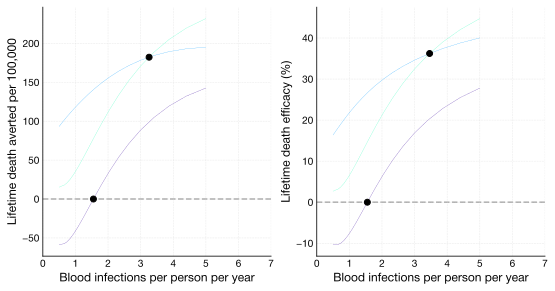

In [2]:
#| output: false

x = sa.sensitivity('ρ_elp', np.linspace(pars.ρ_elp, pars.ρ_elp, 1), β=0, season_width=seasonal_season_width, boosters=1)
fig1, axs = sa.plot(x, pars.ρ_elp)


Here we demonstrate the sensitivity of the model outputs of lifetime deaths averted and lifetime death efficacy against blood infection rate to changes in the model parameters. The two outputs we focus on are:

1. the critical infection rate, $\lambda_\text{RH5}$, at which the combination of R21+RH5 transitions from under-performing to out-performing RH5-alone (R21+RH5 always out-performs R21-alone)
2. the critical infection rate, $\lambda_\text{R21}$, at which the R21-alone vaccine with one booster transitions from indirectly causing deaths to preventing deaths.

For the default parameters of the model we find $\lambda_\text{R21}\approx 1.5$ infections per year and $\lambda_\text{RH5}\approx3.5$ infections per year.

The sensitivity analysis below shows that

- parameters that substantially affect $\lambda_\text{RH5}$ are: 

    - Decay rate age-modifier in risk of severe malaria, $\epsilon_\text{severe}$
    - RH5 protective effect against clinical malaria, $\omega_\text{clinical}$
    - RH5 half-life, $\tau_\text{blood}$

- parameters that substantially affect $\lambda_\text{R21}$ are:

    - Decay rate age-modifier in risk of severe malaria, $\epsilon_\text{severe}$
    - R21 half-life, $\tau_\text{liver}$

Although both critical infection rates $\lambda_\text{R21}$ and $\lambda_\text{RH5}$ depend sensitively on $\epsilon_\text{severe}$, its value is quite constrained around 0.05 per year per infection. If it is much lower than 0.05 a second peak in deaths in 5 to 10 year olds occurs at low blood infection rates, which is not observed in the epidemiological data. If it is much higher than 0.05 it overly suppresses deaths in the 5 to 10 year olds, which do occur.

RH5's protective effect against clinical malaria, $\omega_\text{clinical}$, needs to be determined as it is currently unknown. This will probably only be achieved by counting all infections (clinical and asymptomatic) in the control and vaccine arms of future trials. 

# Early life protection parameters

Early life protection from infection wanes from a maximum $\rho_\text{elp}$ at birth to zero with a half-life of $\tau_\text{elp}$ years.

## Early life protection from infection at birth, $\rho_\text{elp}$

Early life protection from infection at birth, $\rho_\text{elp}$, is estimated to be `{python} f'{pars.ρ_elp:.2f}'` in the Senegalese villages of Ndiop and Dielmo ([Notebook S5](S5_clinical_immunity.ipynb); @trape_1996; @trape_one_2024). In [@fig-rho_elp] $\rho_\text{elp}$ varies from 0.5 to 1 (default is `{python} f'{pars.ρ_elp:.2f}'`). 

Changing this parameter is similar to changing infection rate by a small amount, which causes the curves to shift horizontally. It has a small quantitative effect on $\lambda_\text{R21}$ and $\lambda_\text{RH5}$. But qualitatively it has no effect on the conclusions of the paper.

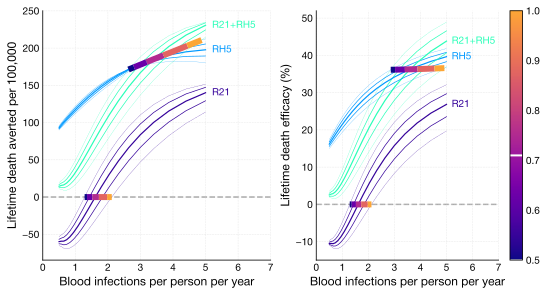

In [3]:
#| label: fig-rho_elp
#| fig-cap: "Early life protection from infection at birth, $\\rho_\\text{elp} = (0.5, 1)$. The default value is shown as a white line in the colorbar. For a given value of $\\rho_\\text{elp}$ and for each vaccine strategy (R21-alone, RH5-alone and RH5+R21 combined, all with one booster) we run 20 simulations across the range of infection rates from 0.5 to 5 blood infections per year. The point of intersection of the R21+RH5 line and the RH5 line is the critical threshold $\\lambda_\\text{RH5}$. And the point of intersection of the R21 line with the $x$-axis is the critical threshold $\\lambda_\\text{R21}$. We repeat the process for five different values of $\\rho_\\text{elp}$ equally spaced between 0.5 and 1 inclusive. The resulting five values of $\\lambda_\\text{RH5}$ are joined by a coloured line with the colour representing the value of $\\rho_\\text{elp}$ which is shown in the colorbar. The same is done for $\\lambda_\\text{R21}$. Thus the coloured lines show the sensitivity of the two critical thresholds to changes in $\\rho_\\text{elp}$."

ρ_elp = sa.sensitivity('ρ_elp', np.linspace(0.5, 1, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(ρ_elp, pars.ρ_elp)


## Half-life of early life protection from infection, $\tau_\text{elp}$

Half-life of early life protection from infection, $\tau_\text{elp}$, is estimated to be `{python} f'{pars.τ_elp:.2f}'` years in the Senegalese villages of Ndiop and Dielmo ([Notebook S5](S5_clinical_immunity.ipynb), @trape_1996, @trape_one_2024). The infection data in Figure 2A of @goncalves_parasite_2014, suggests that early life protection wanes within the six months of life. In [@fig-tau_elp] it varies from 0.5 to 2.5 years (default is `{python} f'{pars.τ_elp:.2f}'` years). 

As for $\rho_\text{elp}$, changing this parameter is similar to changing infection rate. Again the quantitative effects on $\lambda_\text{R21}$ and $\lambda_\text{RH5}$ are small but with no qualitative effect.

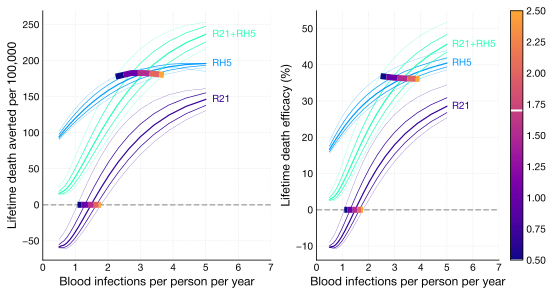

In [ ]:
#| label: fig-tau_elp
#| fig-cap: "Half-life of early life protection from infection, $\\tau_\\text{elp} = (0.5, 2.5)$ years."

τ_elp = sa.sensitivity('τ_elp', np.linspace(0.5, 2.5, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(τ_elp, pars.τ_elp)


# Clinical immunity parameters

The risk of clinical malaria declines sigmoidally with exposure (i.e., cumulative number of infections). On first infection the relative risk is given by $\rho_\text{clinical}$. The half-maximum-risk exposure is given by $\gamma_\text{clinical}$, and the rate of decline of risk at half-maximum-risk is proportional to $\delta_\text{clinical}$. 

## Relative risk of clinical malaria on first infection, $\rho_\text{clinical}$

Relative risk of clinical malaria on first infection, $\rho_\text{clinical}$, is estimated to be 0.8 ([Notebook S4](S4_goncalves.ipynb), @goncalves_parasite_2014). In the individual-level data for Dielmo village it varied from about 0.2 to 1 ([Notebook S5](S5_clinical_immunity.ipynb), @trape_1996, @trape_one_2024). In [@fig-rho_clinical] it varies from 0.20 to 1 (default is `{python} f'{pars.ρ_clinical:.2f}'`). 

This parameter scales clinical malaria age patterns but does not alter infection rate. It therefore affects the number of averted deaths (fewer clinical episodes implies fewer severe malaria episodes and deaths) but it does not affect the critical infection rates $\lambda_\text{R21}$ and $\lambda_\text{RH5}$. Moreover, because it affects unvaccinated and vaccinated children equally, death efficacies are unchanged.

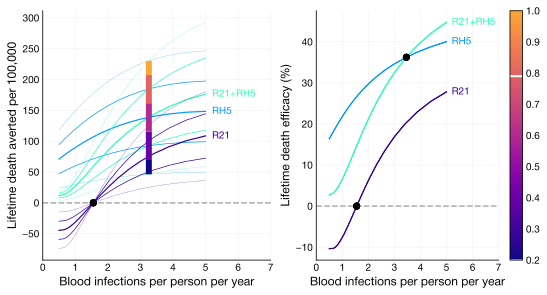

In [5]:
#| label: fig-rho_clinical
#| fig-cap: " Relative risk of clinical malaria on first infection, $\\rho_\\text{clinical} = (0.20, 1)$."

ρ_clinical = sa.sensitivity('ρ_clinical', np.linspace(0.20, 1.0, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(ρ_clinical, pars.ρ_clinical)


## Half-maximum-risk exposure of clinical malaria, $\gamma_\text{clinical}$

Half-maximum-risk exposure of clinical malaria, $\gamma_\text{clinical}$ is estimated to be `{python} f'{pars.γ_clinical:.2f}'` infections for the population-level data of Dielmo and Ndiop villages. In the individual-level data for Dielmo village it varied from about 10 to 200 infections ([Notebook S5](S5_clinical_immunity.ipynb), @trape_1996, @trape_one_2024). In [@fig-gamma_clinical] it varies from 10 to 200 infections (default is `{python} f'{pars.γ_clinical:.2f}'` infections). 

This parameter changes clinical age patterns in older children so it has negligible effect on severe and death age patterns and negligible effect on the critical infection rates. 

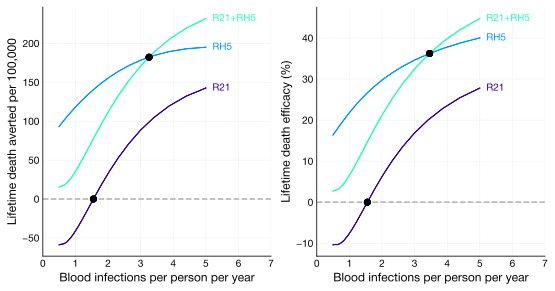

In [6]:
#| label: fig-gamma_clinical
#| fig-cap: "Half-maximum risk exposure of clinical malaria, $\\gamma_\\text{clinical} = (10, 200)$ infections."

γ_clinical = sa.sensitivity('γ_clinical', np.linspace(10, 200, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(γ_clinical, pars.γ_clinical)


## Rate of development of clinical immunity with exposure, $\delta_\text{clinical}$

Rate of development of clinical immunity with exposure, $\delta_\text{clinical}$, is estimated to be `{python} f'{pars.δ_clinical:.2f}'` per infection for Dielmo and Ndiop villages. In the individual-level data for Dielmo village it varied from about 0.01 to 0.06 per infection ([Notebook S5](S5_clinical_immunity.ipynb), @trape_1996, @trape_one_2024). In [@fig-delta_clinical] it varies from 0.01 to 0.1 (default is `{python} f'{pars.δ_clinical:.2f}'` per infection). 

This parameter changes clinical age patterns in older children so it has negligible effect on severe and death age patterns and negligible effect on the critical infection rates.

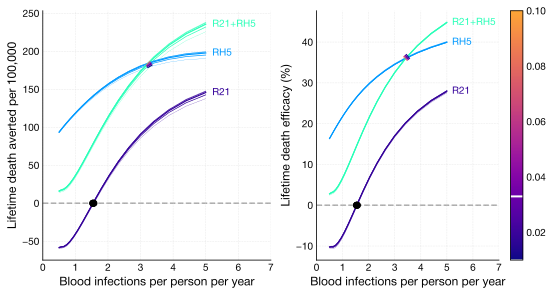

In [7]:
#| label: fig-delta_clinical
#| fig-cap: "Rate of development of clinical immunity with exposure, $\\delta_\\text{clinical} = (0.01, 0.1)$ per infection."

δ_clinical = sa.sensitivity('δ_clinical', np.linspace(0.01, 0.1, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(δ_clinical, pars.δ_clinical)


# Severe malaria immunity parameters

The risk of a severe episode becoming severe declines exponentially with age-dependent exposure. On first infection, the relative risk is $\rho_\text{severe}$. The rate of decline in risk is $\delta_\text{severe}+\epsilon_\text{severe}a$ where $\delta_\text{severe}$ is the rate in decline of risk in newborns and $\epsilon_\text{severe}$ is an age-modification parameter that increases the rate of decline in risk with age $a$.  

## Relative risk of severe malaria on first infection, $\rho_\text{severe}$

Relative risk of severe malaria on first infection, $\rho_\text{severe}$ is estimated to be `{python} f'{pars.ρ_severe:.2f}'` ([Notebook S4](S4_goncalves.ipynb); @goncalves_parasite_2014; @munoz_sandoval_plasmodium_2025). In [@fig-rho_severe] it varies from 0.01 to 0.08 (default `{python} f'{pars.ρ_severe:.2f}'`). 

This parameter scales the number of severe malaria episodes without changing the shape of severe malaria and death age patterns. So deaths averted is scaled, but death efficacy is left unchanged.

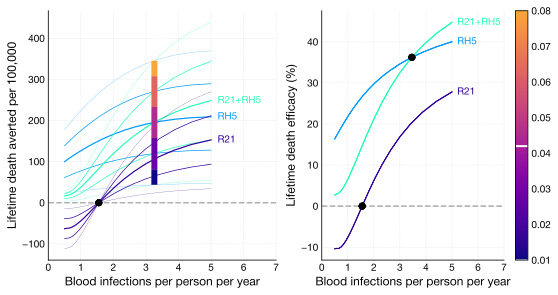

In [8]:
#| label: fig-rho_severe
#| fig-cap: "Relative risk of severe malaria on first infection, $\\rho_\\text{severe} = (0.01, 0.08)$."

ρ_severe = sa.sensitivity('ρ_severe', np.linspace(0.01, 0.08, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(ρ_severe, pars.ρ_severe)


## Rate of decline in risk of severe malaria with exposure in newborns, $\delta_\text{severe}$

Rate of decline in risk of severe malaria with exposure in newborns, $\delta_\text{severe}$ is estimated to be `{python} f'{pars.δ_severe:.2f}'` per infection ([Notebook S4](S4_goncalves.ipynb), @goncalves_parasite_2014, @munoz_sandoval_plasmodium_2025). In [@fig-delta_severe] it varies from 0.05 to 0.25 per infection (default `{python} f'{pars.δ_severe:.2f}'` per infection). 

This parameter changes the rate of development of severe immunity. Hence increasing this parameter causes the severe malaria age pattern to peak at earlier ages thereby reducing overall death rate which in turn reduces the impact vaccines have on averted deaths. The effect on $\lambda_\text{R21}$ is negligible. The effect on $\lambda_\text{RH5}$ is small.

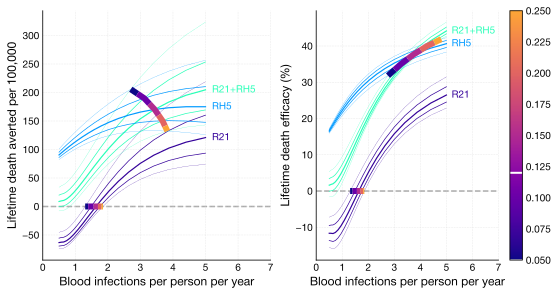

In [9]:
#| label: fig-delta_severe
#| fig-cap: "Rate of decline in risk of severe malaria with exposure in newborns, $\\delta_\\text{severe} = (0.05, 0.25)$ per infection."

δ_severe = sa.sensitivity('δ_severe', np.linspace(0.05, 0.25, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(δ_severe, pars.δ_severe)


## Decay rate age-modifier in risk of severe malaria, $\epsilon_\text{severe}$

Decay rate age-modifier in risk of severe malaria, $\epsilon_\text{severe}$ is estimated to be about `{python} f'{pars.ε_severe:.2f}'` per year per infection ([Notebook S6](S6_severe_malaria_immunity.ipynb)). This estimate is not based on formal fitting to data, but on its ability to recapitulate mortality age patterns [@abdullah_patterns_2007]. There is, therefore, some uncertainty in its value. However, values lower than 0.05 cause a second peak in deaths in 5 to 10 year olds, which is not observed in epidemiological data. Values higher than 0.05 tend to suppress deaths in the 5 to 10 year olds, which are known to occur (see for example, @abdullah_patterns_2007, @reyburn_association_2005). In [@fig-epsilon_severe] it varies from 0.035 to 0.75 per year per infection (default `{python} f'{pars.ε_severe:.2f}'` per year per infection). 

The effect of this parameter on the averted deaths and efficacies curves is complex. And $\lambda_\text{R21}$ and $\lambda_\text{RH5}$ are both sensitive to its value.

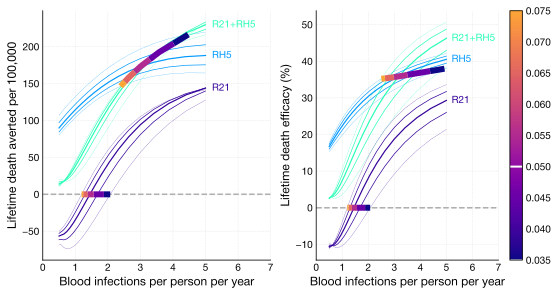

In [10]:
#| label: fig-epsilon_severe
#| fig-cap: "Age modification rate in decline in risk of severe malaria, $\\epsilon\\text{severe} = (0.035, 0.075)$ per infection per year."

ε_severe = sa.sensitivity('ε_severe', np.linspace(0.035, 0.075, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(ε_severe, pars.ε_severe)


# Strength of severe malaria-associated age-specific risk of death

Severe malaria-associated age-specific risk of death is estimated from @reyburn_association_2005. The default risk is shown as a dashed line in @fig-reyburn (see [Notebook S7](S7_death_rate.ipynb)). The model parameter `death_rate_modifier` attenuates the strength of age-specificity. A value of 1 corresponds to the blue dashed line in @fig-reyburn. A value of zero completely removes age-specificity and the risk of death is a constant 0.067 across all ages (green line). This is the mean risk of death in the @reyburn_association_2005 data.

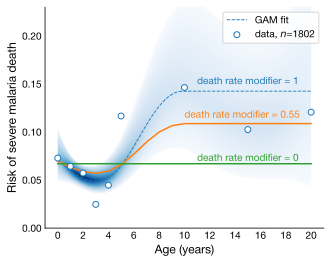

In [11]:
#| label: fig-reyburn
#| fig-cap: "Estimated severe malaria-associated mean age-specific risk of death (dashed line) with 95% CI (blue band) and age-stratified data (circles) from @reyburn_association_2005."

fig, ax = sa.death_rate_modifier()

In [@fig-death_rate_modifier] `death_rate_modifier` varies from 0.55 to 1 (default is `{python} f'{pars.death_rate_modifier}'`). 

Attenuating the age-specificity of the risk of death means that children aged over five have more similar death rates to children under five. So the rebound in deaths in the over fives caused by R21 is weakened. This causes the R21 curves in [@fig-death_rate_modifier] to move upward resulting in $\lambda_\text{R21}$ moving toward zero. For `death_rate_modifier` less than about 0.6 $\lambda_\text{R21}$ is zero and therefore R21 cannot indirectly cause deaths.

Similarly for the combined R21+RH5.1 vaccine, rebound is weakened causing the R21+RH5.1 curves to move upward and $\lambda_\text{RH5}$ to decrease.

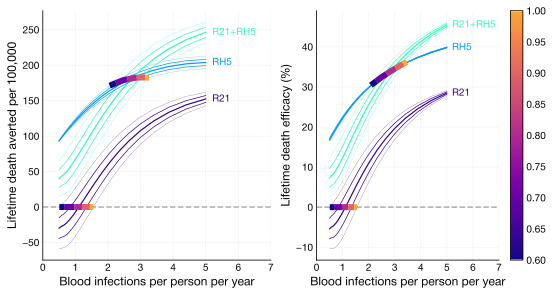

In [ ]:
#| label: fig-death_rate_modifier
#| fig-cap: "Attenuation of severe malaria-associated age-specific risk of death, `death_rate_modifier` = (0.6, 1)."

death_rate_modifier = sa.sensitivity('death_rate_modifier', np.linspace(0.6, 1, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig1, axs = sa.plot(death_rate_modifier, pars.death_rate_modifier)


# Blood infection rate heterogeneity, $\beta$

The parameter $\beta$ determines the degree of heterogeneity in blood infection rate in the population, with 0 being completely homogeneous, and 1 being maximally heterogeneous (modelled assuming a symmetric triangular distribution of infection rates from 0 to twice the mean annual infection rate, see @rodriguez-barraquer_quantifying_2016). In [@fig-beta] it varies from 0 to 1 (default is 1). 

Its effect on lifetime averted deaths and efficacy is negligible and, therefore, its effect on the two critical infection rates is also negligible.

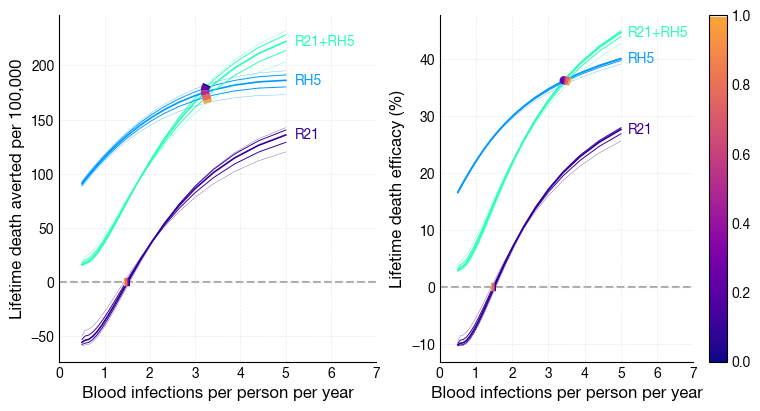

In [2]:
#| label: fig-beta
#| fig-cap:  "Blood infection rate heterogeneity, $\\beta = (0, 1)$."

beta = sa.sensitivity('β', np.linspace(0, 1, 5), β=β, season_width=seasonal_season_width, boosters=1, code='python')
fig, axs = sa.plot(beta, 1)


# R21 vaccine parameters

The R21 protection profile against blood infection we use is estimated in @schmit_public_2024. There are two parameters we can change that affect this profile: the maximum efficacy just after the last primary dose $\nu_\text{liver}$, and the vaccine's half-life $\tau_\text{liver}$. We can also change the number of yearly boosters. 

## R21's maximum efficacy against infection, $\nu_\text{liver}$

R21's maximum efficacy, $\nu_\text{liver}$ scales protective efficacy against infection, where $\nu_\text{liver}=1$ corresponds to the same efficacy profile as in @schmit_public_2024. In [@fig-nu_liver] it varies from 0.5 to 1 (default is `{python} f'{pars.ν_liver:.2f}'`). 

R21 temporarily reduces infection rate which delays infection, but it does not directly prevent death. Whether it indirectly prevents or causes deaths depends on how late into childhood infection is delayed due to the opposing forces of the development of age-dependent severe malaria immunity and age-dependent death rate. The parameter $\nu_\text{liver}$ can have a negative or positive impact on deaths averted and death efficacy depending on infection rate ([@fig-nu_liver]). (Obviously, this parameter has no effect on the RH5-alone vaccine curves.) Whatever its value though, its impact on the critical infection rates is minimal.  

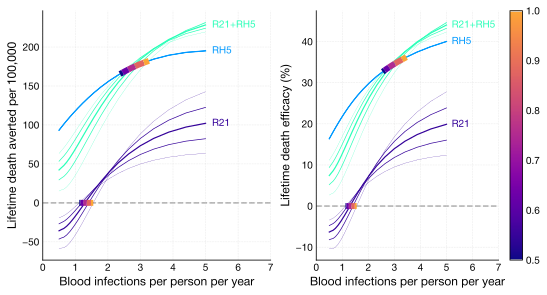

In [14]:
#| label: fig-nu_liver
#| fig-cap:  "R21's maximum efficacy against infection, $\\nu_\\text{liver} = (0.5, 1)$."

ν_liver = sa.sensitivity('ν_liver', np.linspace(0.5, 1., 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(ν_liver, pars.ν_liver)

## R21 half-life, $\tau_\text{liver}$

The parameter $\tau_\text{liver}$ scales the half-life of R21, where $\tau_\text{liver}=1$ corresponds to the same efficacy profile as in @schmit_public_2024. R21 is estimated to have a long half-life of over five years [@schmit_public_2024].  In [@fig-tau_liver] it varies from 0.5 to 3 (default is `{python} f'{pars.τ_liver:.2f}'`). 

Because R21's half-life is estimated to be about five years, it has little effect on lifetime averted deaths and efficacy [@fig-tau_liver]. It has negligible effect on $\lambda_\text{RH5}$, but higher half-lives can substantially lower $\lambda_\text{R21}$.

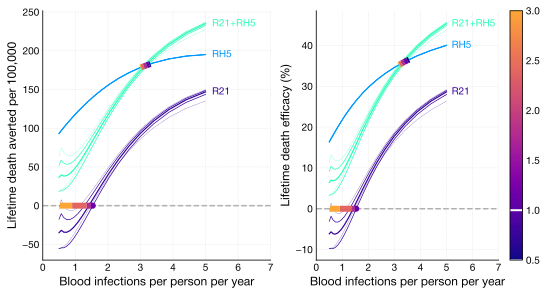

In [15]:
#| label: fig-tau_liver
#| fig-cap:  "R21 half-life, $\\tau_\\text{liver} = (0.5, 3)$."

τ_liver = sa.sensitivity('τ_liver', np.linspace(0.5, 3, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(τ_liver, pars.τ_liver)

## Number of R21 boosters

Increasing the number of R21 boosters is similar to slightly increasing its half-life: the protective efficacy of the vaccine lasts a little longer.  In [@fig-nboosters_liver] it varies from 0 to 4 (default is 1). 

It has negligible effect on the critical transmission rates.

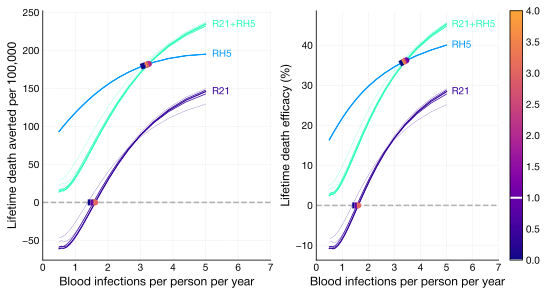

In [16]:
#| label: fig-nboosters_liver
#| fig-cap:  "Number of R21 boosters = $0, \\hdots, 4$."

nboosters_liver = sa.sensitivity('nboosters_liver', np.arange(0, 5, dtype=int), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(nboosters_liver, 1)


# RH5 vaccine parameters

The RH5 protection profile against blood infection, clinical malaria and severe malaria is assumed to mirror its anti-RH5.1 IgG antibody profile ([@silk_blood-stage_2024], [Notebook S9](S9_RH5.ipynb)). There is one parameter we can change that affect this profile: the vaccine's half-life $\tau_\text{blood}$. We can also change the number of yearly boosters. 

Data from the phase 2b trial of the RH5.1/Matrix-M blood stage vaccine ([@natama_safety_2024]) and from primate studies demonstrate that RH5 reduces parasite growth rate and parasitaemia at clinical presentation. But the data are equivocal about the degree to which RH5 reduces the risks of blood infection, clinical malaria and severe malaria. There are three model parameters that determine these reduced risks, $\omega_\text{infection}$, $\omega_\text{clinical}$ and $\omega_\text{severe}$, respectively.

## RH5 half-life, $\tau_\text{blood}$

The parameter $\tau_\text{blood}$ scales the half-life of RH5, where $\tau_\text{blood}=1$ corresponds to the default parameter setting.  In [@fig-tau_blood] it varies from 0.5 to 2 (default is 1). 

RH5 is estimated to have a short half-life of about six months. Hence increasing this parameter has a large effect on lifetime averted deaths and efficacy. It has a substantial impact on $\lambda_\text{RH5}$. It has no effect on $\lambda_\text{R21}$.

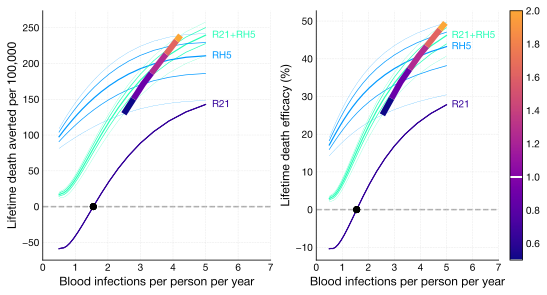

In [17]:
#| label: fig-tau_blood
#| fig-cap:  "RH5 half-life, $\\tau_\\text{blood} = (0.5, 2)$ default 1."

τ_blood = sa.sensitivity('τ_blood', np.linspace(0.5, 2, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(τ_blood, pars.τ_blood)

## Number of RH5 boosters

Increasing the number of RH5 boosters is similar to increasing its half-life: the protective efficacy of the vaccine lasts longer. In [@fig-nboosters_blood] it varies from 0 to 4 (default is 1). 

The effect on $\lambda_\text{RH5}$ is complex, albeit small.

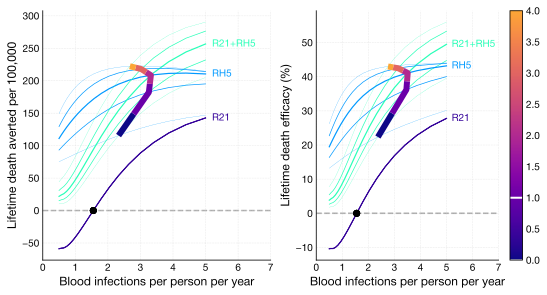

In [18]:
#| label: fig-nboosters_blood
#| fig-cap:  "Number of RH5 boosters = $0, \\hdots, 4$, default 1."

nboosters_blood = sa.sensitivity('nboosters_blood', np.arange(0, 5), β=β, season_width=seasonal_season_width, boosters=1)
fig, axs = sa.plot(nboosters_blood, 1)

## RH5 protective effect against blood infection, $\omega_\text{infection}$

RH5 protective effect against blood infection, $\omega_\text{infection}$, is estimated in [Notebook S9](S9_RH5.ipynb). We estimated its value to be either 0% if RH5 does not protect against blood infection, to 43% if it does. In [@fig-omega_infection] it varies from 0 to 1 (default `{python} f'{pars.ω_infection:.2f}'`).

Increasing this parameter makes RH5 behave more like R21 (with a shorter half-life). Therefore the averted deaths and efficacy curves tend towards the R21-alone curves. This has the effect of reducing averted deaths and efficacy. However, there is minimal effect on $\lambda_\text{RH5}$.

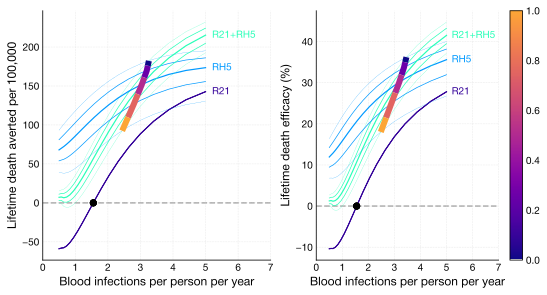

In [19]:
#| label: fig-omega_infection
#| fig-cap:  "RH5 protective effect against blood infection, $\\omega_\\text{infection} = (0, 1)$."

ω_infection = sa.sensitivity('ω_infection', np.linspace(0, 1, 5), β=β, season_width=seasonal_season_width, boosters=1, protection_blood=None)
fig, axs = sa.plot(ω_infection, pars.ω_infection)


## RH5 protective effect against clinical malaria, $\omega_\text{clinical}$

RH5 protective effect against clinical malaria is estimated in [Notebook S9](S9_RH5.ipynb). We estimated its value to be about 50% when RH5 does not protect against blood infection. In [@fig-omega_clinical] it varies from 0 to 0.6 (default `{python} f'{pars.ω_clinical:.2f}'`). 

The parameter reduces the risk of clinical malaria, and hence severe malaria and death. Increasing it, therefore, increases lifetime deaths averted and lifetime efficacy. It has a substantial effect on $\lambda_\text{RH5}$, therefore it is an important to refine its value with more precision.

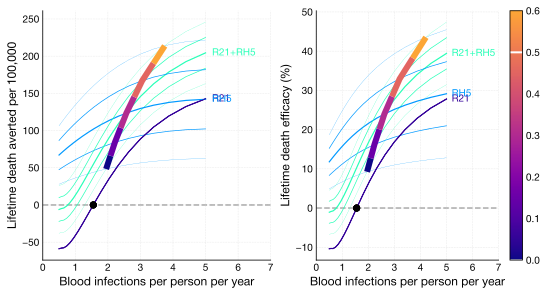

In [20]:
#| label: fig-omega_clinical
#| fig-cap:  "RH5 protective effect against clinical malaria, $\\omega_\\text{clinical} = (0, 0.6)$."

ω_clinical = sa.sensitivity('ω_clinical', np.linspace(0, 0.6, 5), β=β, season_width=seasonal_season_width, boosters=1, protection_blood=None)
fig, axs = sa.plot(ω_clinical, pars.ω_clinical)


## RH5 protective effect against severe malaria, $\omega_\text{severe}$

RH5 protective effect against severe malaria is estimated in [Notebook S9](S9_RH5.ipynb). We estimated its value to be `{python} f'{pars.ω_severe:.2f}'` based on fold-reduction in parasitaemia at presentation. In [@fig-omega_severe] it varies from 0 to 0.5 (default `{python} f'{pars.ω_severe:.2f}'`). 

The parameter reduces the risk of severe malaria, and hence death. Increasing it, therefore, increases lifetime deaths averted and lifetime efficacy. It has a minimal effect on $\lambda_\text{RH5}$.

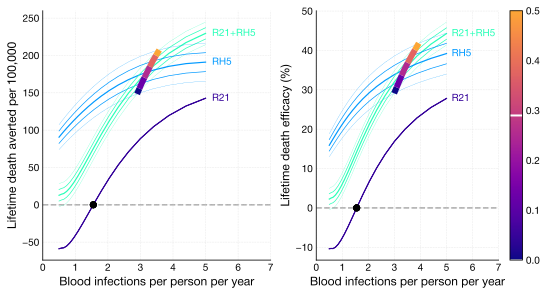

In [21]:
#| label: fig-omega_severe
#| fig-cap:  "RH5 protective effect against severe malaria, $\\omega_\\text{severe} = (0, 0.5)$."

ω_severe = sa.sensitivity('ω_severe', np.linspace(0, 0.5, 5), β=β, season_width=seasonal_season_width, boosters=1, protection_blood=None)
fig, axs = sa.plot(ω_severe, pars.ω_severe)


::: {#refs}
:::